In [48]:
import pandas as pd

df = pd.read_csv('/content/googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000",Free,0,Everyone,Art & Design,January 7 2018,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"5,00,000",Free,0,Everyone,Art & Design;Pretend Play,January 15 2018,2.0.0,4.0.3 and up
2,U Launcher Lite – FREE Live Cool Themes Hide Apps,ART_AND_DESIGN,4.7,87510,8.7M,"50,00,000",Free,0,Everyone,Art & Design,August 1 2018,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"5,00,00,000",Free,0,Teen,Art & Design,June 8 2018,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"1,00,000",Free,0,Everyone,Art & Design;Creativity,June 20 2018,1.1,4.4 and up


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  object 
 1   Category        10358 non-null  object 
 2   Rating          8893 non-null   float64
 3   Reviews         10358 non-null  object 
 4   Size            10358 non-null  object 
 5   Installs        10358 non-null  object 
 6   Type            10357 non-null  object 
 7   Price           10358 non-null  object 
 8   Content Rating  10357 non-null  object 
 9   Genres          10358 non-null  object 
 10  Last Updated    10358 non-null  object 
 11  Current Ver     10350 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

,0
App,483
Category,483
Rating,1948
Reviews,483
Size,483
Installs,483
Type,484
Price,483
Content Rating,484
Genres,483


# Remove duplicates

In [20]:
df = df.drop_duplicates()

# Check missing values

In [8]:
df.isnull().sum()

,0
App,1
Category,1
Rating,1466
Reviews,1
Size,1
Installs,1
Type,2
Price,1
Content Rating,2
Genres,1


# Check missing values

In [21]:
df=df.dropna()

In [23]:
df = df[df['Rating'] <= 5]

In [25]:
df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [27]:
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

#Clean Reviews

In [28]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

#Clean Size

In [29]:
df['Size'] = df['Size'].astype(str)
df['Size'] = df['Size'].str.replace('Varies with device', '', regex=False)
df['Size'] = df['Size'].str.replace('M', '', regex=False)
df['Size'] = df['Size'].str.replace('k', '', regex=False)
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

#Remove Missing Values

In [30]:
df = df.dropna()

In [31]:
df.isnull().sum()
df.shape

(7418, 13)

#Average Rating

In [32]:
df['Rating'].mean()

np.float64(4.1713939067134)

#Unique Categories

In [33]:
df['Category'].nunique()

33

#Free vs Paid

In [34]:
df['Type'].value_counts()

,count
Type,
Free,6873
Paid,545


#Top 5 Apps by Installs

In [35]:
df.sort_values(by='Installs', ascending=False).head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9363,Google News,NEWS_AND_MAGAZINES,3.9,878065,13.0,1000000000,Free,0.0,Teen,News & Magazines,August 1 2018,5.2.0,4.4 and up
1540,Subway Surfers,GAME,4.5,27724094,76.0,1000000000,Free,0.0,Everyone 10,Arcade,July 12 2018,1.90.0,4.1 and up
1493,Subway Surfers,GAME,4.5,27723193,76.0,1000000000,Free,0.0,Everyone 10,Arcade,July 12 2018,1.90.0,4.1 and up
1655,Subway Surfers,GAME,4.5,27725352,76.0,1000000000,Free,0.0,Everyone 10,Arcade,July 12 2018,1.90.0,4.1 and up
1447,Subway Surfers,GAME,4.5,27722264,76.0,1000000000,Free,0.0,Everyone 10,Arcade,July 12 2018,1.90.0,4.1 and up


#Apps with Rating ≥ 4

In [36]:
df[df['Rating'] >= 4].shape[0]

5661

#Average Reviews (Free vs Paid)

In [37]:
df.groupby('Type')['Reviews'].mean()

,Reviews
Type,
Free,300562.116543
Paid,7027.088073


#Category vs Installs

In [38]:
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(5)

,Installs
Category,
GAME,26802452717
FAMILY,6696812580
TOOLS,3525553500
COMMUNICATION,3336915530
NEWS_AND_MAGAZINES,3214900550


In [39]:
df[['Installs','Rating','Reviews','Size','Price']].corr()

,Installs,Rating,Reviews,Size,Price
Installs,1.000000,0.054350,0.632032,0.016446,-0.010627
Rating,0.054350,1.000000,0.080456,-0.019977,-0.021941
Reviews,0.632032,0.080456,1.000000,0.034841,-0.010015
Size,0.016446,-0.019977,0.034841,1.000000,0.018730
Price,-0.010627,-0.021941,-0.010015,0.018730,1.000000


#Rating Distribution

In [41]:
import matplotlib.pyplot as plt

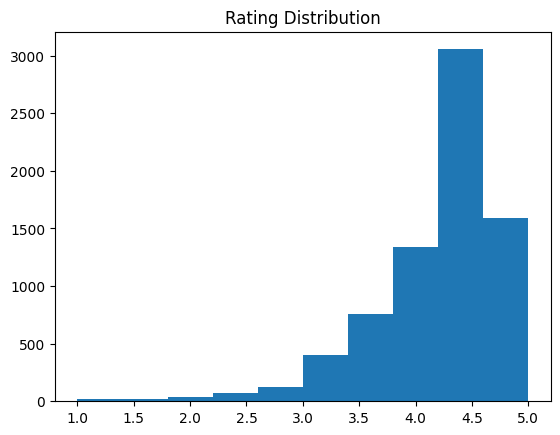

In [42]:
plt.hist(df['Rating'])
plt.title("Rating Distribution")
plt.show()

#Free vs Paid Chart

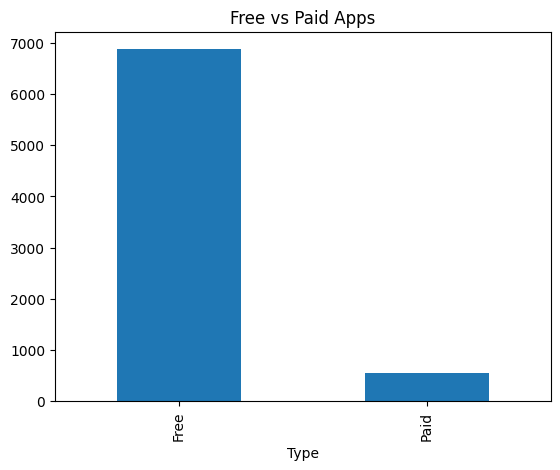

In [43]:
df['Type'].value_counts().plot(kind='bar')
plt.title("Free vs Paid Apps")
plt.show()

#Installs vs Rating

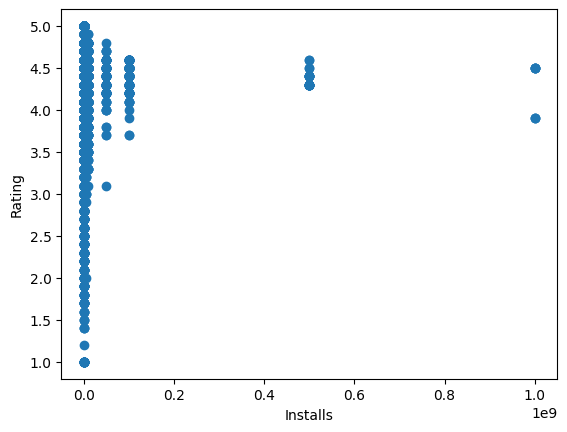

In [44]:
plt.scatter(df['Installs'], df['Rating'])
plt.xlabel("Installs")
plt.ylabel("Rating")
plt.show()

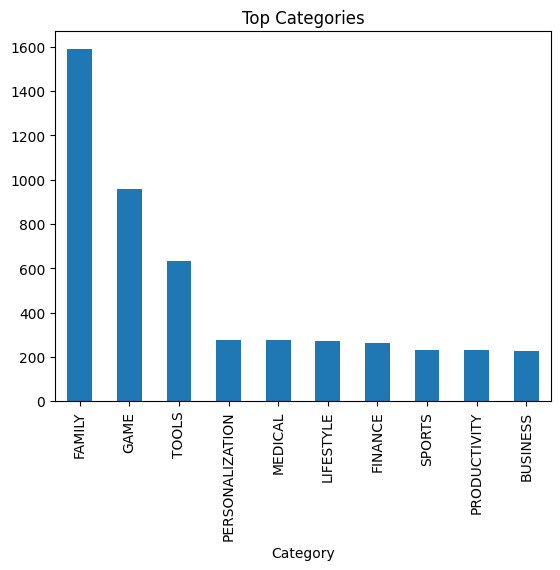

In [46]:
df['Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Categories")
plt.show()